In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    

Using notebook 3d backend.


In [132]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'PhonemeSequence', 
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        'SentenceRep'
        ]


ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='time',
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
# rename CG to Cingulate cortex
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'

HGAs.head()

100%|██████████| 1140/1140 [00:18<00:00, 63.07it/s] 


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,stimulus,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


In [133]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 257984
PIC electrode count: 223296


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,stimulus,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


In [134]:
subset = HGAs[
    (HGAs.modality == 'sound')
    & (HGAs.description == 'Repeat')
].copy()

subset['significance'] = subset.groupby(['task', 'channel'])['mask'].transform('any')
subset = subset[subset.significance==True]
subset = subset[subset.roi.isin(['AIC','PIC']) & (subset.hemi == 'L')]
subset.head()

,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z,significance
2,-1.000000,D0022_LPIF4-5,0.026676,False,PIC,L,D0022,Repeat,PhonemeSequence,go,sound,ctx_lh_S_circular_insula_inf,-40.742572,-20.437126,-4.055261,True
5,-0.992188,D0022_LPIF4-5,0.036907,False,PIC,L,D0022,Repeat,PhonemeSequence,go,sound,ctx_lh_S_circular_insula_inf,-40.742572,-20.437126,-4.055261,True
8,-0.984375,D0022_LPIF4-5,0.053311,False,PIC,L,D0022,Repeat,PhonemeSequence,go,sound,ctx_lh_S_circular_insula_inf,-40.742572,-20.437126,-4.055261,True
11,-0.976562,D0022_LPIF4-5,0.078211,False,PIC,L,D0022,Repeat,PhonemeSequence,go,sound,ctx_lh_S_circular_insula_inf,-40.742572,-20.437126,-4.055261,True
14,-0.968750,D0022_LPIF4-5,0.090279,False,PIC,L,D0022,Repeat,PhonemeSequence,go,sound,ctx_lh_S_circular_insula_inf,-40.742572,-20.437126,-4.055261,True


In [303]:
import xarray as xr

stimulus_stage = (subset[(subset.phase=='stimulus') 
                         &(subset.time>-0.5)
                         &(subset.time<1)]
    .groupby(['channel','time'])['value']
    .mean()
    .to_xarray()
)

go_stage = (subset[(subset.phase=='go') 
                         &(subset.time>-0.5)
                         &(subset.time<1)]
    .groupby(['channel','time'])['value']
    .mean()
    .to_xarray()
)

response_stage = (subset[(subset.phase=='response') 
                         &(subset.time>-0.5)
                         &(subset.time<1)]
    .groupby(['channel','time'])['value']
    .mean()
    .to_xarray()
)

stimulus_stage = stimulus_stage - stimulus_stage.mean(dim='time')
go_stage = go_stage - go_stage.mean(dim='time')
response_stage = response_stage - response_stage.mean(dim='time')

# concat
# concat_stage = xr.concat([stimulus_stage, go_stage, response_stage], dim='time')
concat_stage = xr.concat([stimulus_stage,go_stage,response_stage], dim='time')
# 把所有 NaN 设为 0
concat_stage = concat_stage.fillna(0)
valid_channels = concat_stage.dropna(dim='channel', how='any').channel.values
concat_stage = concat_stage.sel(channel=valid_channels)

In [308]:
# perform the NMF
from sklearn.decomposition import NMF
from sklearn.preprocessing import RobustScaler

# Prepare data for NMF (channels x timepoints)
data_matrix = concat_stage.values
# data_matrix = data_matrix-np.mean(data_matrix, axis=-1, keepdims=True)

low, high = np.percentile(data_matrix, [1, 99])
data_matrix = np.clip(data_matrix, low, high)
 
data_matrix = data_matrix - data_matrix.min()

# Apply NMF
n_components = 2  # You can adjust this number
nmf = NMF(n_components=n_components, random_state=42)
W = nmf.fit_transform(data_matrix)  # Channel components
H = nmf.components_  # Temporal components

In [309]:
# Get channel coordinates from valid channels only, preserving concat_stage order
valid_channels = concat_stage.channel.values
coords = (subset[subset.channel.isin(valid_channels)]
          .groupby('channel').agg({
              'x': 'first',
              'y': 'first', 
              'z': 'first',
              'roi': 'first',
              'label': 'first',
              'hemi': 'first',
              'subject': 'first'
          })
          .loc[valid_channels]
          .reset_index())

# Assign each channel to component 0 or 1 based on larger weight
W_df = pd.DataFrame(W, columns=[f'component_{i}' for i in range(n_components)])
W_df['component'] = (W_df['component_1']*1 > W_df['component_0']).astype(int)
W_df['weight'] = np.where(
    W_df['component'] == 1,
    W_df['component_1'],
    W_df['component_0']
)

W_ = pd.concat([coords.reset_index(drop=True), W_df], axis=1)

W_.loc[W_.component==1, 'weight'] *= 1.2

W_.head()


,channel,x,y,z,roi,label,hemi,subject,component_0,component_1,component,weight
0,D0022_LPIF3-4,-34.587586,-19.677040,-2.311079,PIC,ctx_lh_S_circular_insula_inf,L,D0022,1.145463,0.134058,0,1.145463
1,D0022_LPIF4-5,-40.742572,-20.437126,-4.055261,PIC,ctx_lh_S_circular_insula_inf,L,D0022,1.086079,0.191127,0,1.086079
2,D0027_LAI2-3,-32.470676,9.175895,4.597974,AIC,ctx_lh_S_circular_insula_sup,L,D0027,0.580182,0.571171,0,0.580182
3,D0027_LAI3-4,-30.700923,13.124481,11.623351,AIC,ctx_lh_S_circular_insula_sup,L,D0027,0.576597,0.577594,1,0.693113
4,D0028_LAI1-2,-34.700069,8.872246,-13.792580,AIC,ctx_lh_G_insular_short,L,D0028,0.481529,0.636165,1,0.763398


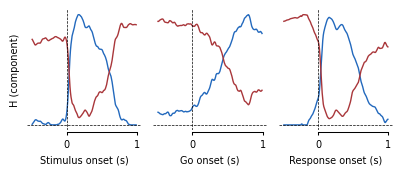

In [310]:
# ====== Split H by real phase lengths and plot ======
time_stim = stimulus_stage.time.values
time_go = go_stage.time.values
time_resp = response_stage.time.values

n_stim = len(time_stim)
n_go = len(time_go)
n_resp = len(time_resp)

phase_slices = [
    ('stimulus', slice(0, n_stim), time_stim, 'Stimulus onset (s)'),
    ('go',       slice(n_stim, n_stim + n_go), time_go, 'Go onset (s)'),
    ('response', slice(n_stim + n_go, n_stim + n_go + n_resp), time_resp, 'Response onset (s)')
]

fig, axes = plt.subplots(1, 3, figsize=(12*cm, 4*cm),
                         gridspec_kw={'width_ratios': [n_stim, n_go, n_resp]})
plt.subplots_adjust(wspace=0.1)

colors = [blue, red]

for ax, (phase, sl, time_vec, xlabel) in zip(axes, phase_slices):
    for comp_idx in range(n_components):
        ax.plot(time_vec, H[comp_idx, sl],
                color=colors[comp_idx], linewidth=1,
                label=f'comp{comp_idx+1}')

    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    sns.despine(ax=ax, offset=1, trim=True)

    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.set_xlabel(xlabel, fontsize=7)

axes[0].set_ylabel('H (component)', fontsize=7)
# axes[0].legend(title='', fontsize=7)

plt.savefig("../img/misc/nmf_temporal.svg", dpi=300, bbox_inches='tight')
plt.show()

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-17 12:05:29.273 (9963.389s) [    7F7E4A95C440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x94ba790): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-17 12:05:29.326 (9963.441s) [    7F7E4A95C440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xa4c6b90): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: eg

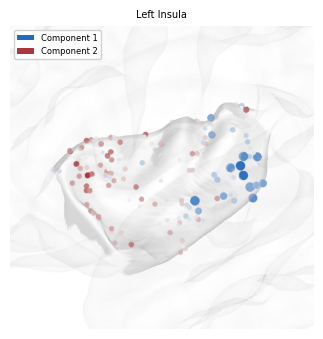

In [311]:
# Pial version - NMF component assignment visualization (focus on insula + label highlight)
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors
import mne
from matplotlib.patches import Patch

# ====== 读取 insula labels ======
labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s', hemi='both', subjects_dir=recon_dir
)
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins',
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

# ====== pial surface + KDTree ======
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        return pial_coords[vertices].mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)

# ====== Brain ======
lh_brain = Brain("fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800))
rh_brain = Brain("fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800))

# ====== insula label 高亮 ======
for lab in labels:
    if any(p in lab.name for p in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

# ====== NMF 数据 ======
coords = W_[['x', 'y', 'z']].values
weight_values = W_['weight'].values
component_values = W_['component'].values

mask_lh = coords[:, 0] < 0
mask_rh = coords[:, 0] > 0

# component 颜色
cmap_dict = {0: blues, 1: reds}
norm_dict = {}
for comp in sorted(np.unique(component_values)):
    comp_weights = weight_values[component_values == comp]
    vmin, vmax = np.percentile(comp_weights, 2), np.percentile(comp_weights, 98)
    norm_dict[comp] = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 点大小映射（全局权重范围）
size_min, size_max = 10, 25
size_vmin, size_vmax = np.percentile(weight_values, 2), np.percentile(weight_values, 98)

def weight_to_size(weight, vmin, vmax, size_min, size_max):
    normalized = np.clip((weight - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

def add_electrodes_with_size(brain, coords, weight_vals, comp_vals, cmap_dict, norm_dict):
    for i in range(len(coords)):
        pt = coords[i:i+1]
        weight = weight_vals[i]
        comp = comp_vals[i]
        cmap = cmap_dict.get(comp, blues)
        norm = norm_dict.get(comp, mcolors.Normalize(vmin=weight_vals.min(), vmax=weight_vals.max()))
        color = cmap(norm(weight))[:3]
        size = weight_to_size(weight, size_vmin, size_vmax, size_min, size_max)

        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud, render_points_as_spheres=True,
            point_size=size, color=color, lighting=False
        )

# 左半球
if mask_lh.any():
    lh_coords = coords[mask_lh]
    lh_weights = weight_values[mask_lh]
    lh_components = component_values[mask_lh]
    _, lh_idx = lh_tree.query(lh_coords)
    lh_coords_on_pial = lh_pial_coords[lh_idx]
    add_electrodes_with_size(lh_brain, lh_coords_on_pial, lh_weights, lh_components, cmap_dict, norm_dict)

# 右半球
if mask_rh.any():
    rh_coords = coords[mask_rh]
    rh_weights = weight_values[mask_rh]
    rh_components = component_values[mask_rh]
    _, rh_idx = rh_tree.query(rh_coords)
    rh_coords_on_pial = rh_pial_coords[rh_idx]
    add_electrodes_with_size(rh_brain, rh_coords_on_pial, rh_weights, rh_components, cmap_dict, norm_dict)

# ====== 视角聚焦 insula ======
lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

# ====== 截图显示 ======
fig, ax = plt.subplots(1, 1, figsize=(10*cm, 10*cm))

ax.imshow(lh_brain.screenshot(mode="rgb"))
ax.axis("off")
ax.set_title("Left Insula", fontsize=fontsize)

legend_elements = [
    Patch(facecolor=blue, label='Component 1'),
    Patch(facecolor=red, label='Component 2'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=fontsize-1, framealpha=0.9)

lh_brain.close()
rh_brain.close()

plt.savefig("../img/misc/nmf_pial.svg", dpi=300, bbox_inches='tight')
plt.show()

ValueError: operands could not be broadcast together with shapes (111,191) (146,1) 

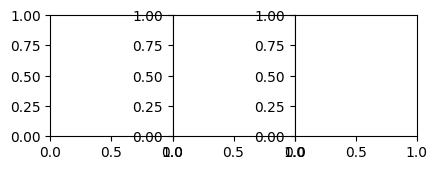

In [240]:

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(12*cm, 4*cm),gridspec_kw={'width_ratios': [2.5, 2.5, 2.5]})

plt.subplots_adjust(wspace=0)

comp_idx = 0

for (ax, phase) in zip(fig.axes, ['stimulus', 'go', 'response']):
    
    # only add the legend to the first axis
    legend = False if ax != fig.axes[0] else True
    
    xdata = (subset[(subset.phase==phase) 
                         &(subset.time>-0.5)
                         &(subset.time<1)
                         &(subset.channel.isin(valid_channels))]
        .groupby(['channel','time'])['value']
        .mean()
        .to_xarray()
    )

    weight = W[:, comp_idx]
    
    this_component = xdata * weight[:, np.newaxis]
    component_signal = this_component.sum(dim='channel')
    
    line = ax.plot(component_signal.time.values,
                   component_signal.values,
                   'b-',
                   linewidth=1)

    # ax.set_ylim(-2, 100)

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    
ax1.set_xlabel('Stimulus onset (s)', fontsize=7)   
ax2.set_xlabel('Go onset (s)', fontsize=7)   
ax3.set_xlabel('Response onset (s)', fontsize=7)   
ax1.set_ylabel('HGA (z)', fontsize=7)
ax2.set_ylabel('', fontsize=7)
ax3.set_ylabel('', fontsize=7)

# plt.suptitle(rois[0] + ' in Lexical Delay', fontsize=7)
# plt.savefig(f'../img/fig4/fig4_{rois[0]}_condition_difference.svg', dpi=300, bbox_inches='tight')

plt.show()